In [1]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("../data/clean_movie_comments.csv")

In [3]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Cleaned Comment"])

y = df["Movie Rating"]

In [4]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [5]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [6]:
print("===== 5-Fold Cross Validation =====\n")

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\n---------------------------")
print(f"Mean Accuracy      : {scores.mean():.4f}")
print(f"Standard Deviation : {scores.std():.4f}")

===== 5-Fold Cross Validation =====

Fold 1: 0.5340
Fold 2: 0.5969
Fold 3: 0.7236
Fold 4: 0.7812
Fold 5: 0.7403

---------------------------
Mean Accuracy      : 0.6752
Standard Deviation : 0.0937


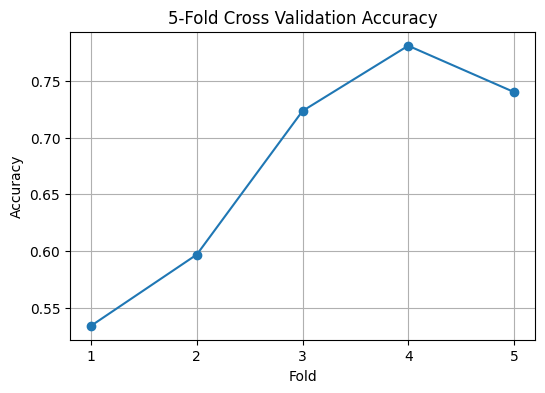

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    range(1,6),
    scores,
    marker="o"
)

plt.xticks(range(1,6))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

plt.grid(True)

plt.show()